=== REAL Quantum Threat Simulation ===
Key Space Size: 10000000
Secret Key: 4721456

Classical Search (REAL):
Attempts: 4721457
Actual Time: 0.0958 seconds

Quantum Search (Grover - Estimated):
Attempts: 3162
Estimated Time: 0.0001 seconds

Speedup Factor ~ 1493.19x


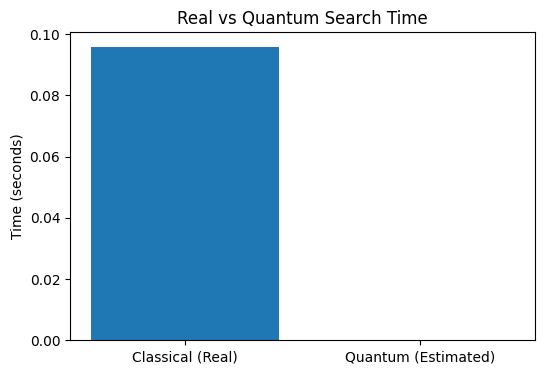

In [ ]:
# ==========================================
# REAL Quantum Threat Simulation (Measured Time)
# ==========================================

import random
import math
import time
import matplotlib.pyplot as plt

# Adjust this value (IMPORTANT)
KEY_SPACE_SIZE = 10_000_000   # 10 million (safe for Colab)

# Random secret key
secret_key = random.randint(0, KEY_SPACE_SIZE - 1)

# ------------------------------------------
# REAL CLASSICAL SEARCH (ACTUAL TIME)
# ------------------------------------------
def classical_search(secret, key_space):
    start_time = time.time()

    for key in range(key_space):
        if key == secret:
            break

    end_time = time.time()
    attempts = key + 1

    return attempts, end_time - start_time

# Run classical search
classical_attempts, classical_time = classical_search(secret_key, KEY_SPACE_SIZE)

# ------------------------------------------
# QUANTUM (THEORETICAL - GROVER)
# ------------------------------------------
quantum_attempts = int(math.sqrt(KEY_SPACE_SIZE))

# Estimate quantum time using scaling
quantum_time_estimated = classical_time * (quantum_attempts / classical_attempts)

# ------------------------------------------
# OUTPUT
# ------------------------------------------
print("=== REAL Quantum Threat Simulation ===")
print(f"Key Space Size: {KEY_SPACE_SIZE}")
print(f"Secret Key: {secret_key}\n")

print("Classical Search (REAL):")
print(f"Attempts: {classical_attempts}")
print(f"Actual Time: {classical_time:.4f} seconds\n")

print("Quantum Search (Grover - Estimated):")
print(f"Attempts: {quantum_attempts}")
print(f"Estimated Time: {quantum_time_estimated:.4f} seconds\n")

print(f"Speedup Factor ~ {classical_attempts / quantum_attempts:.2f}x")

# ------------------------------------------
# GRAPH
# ------------------------------------------
methods = ['Classical (Real)', 'Quantum (Estimated)']
times = [classical_time, quantum_time_estimated]

plt.figure(figsize=(6,4))
plt.bar(methods, times)
plt.title("Real vs Quantum Search Time")
plt.ylabel("Time (seconds)")
plt.show()

In [ ]:
# ==========================================
# EXTENDED ANALYSIS — Multi Key-Space Scaling
# ==========================================
import numpy as np

key_spaces = [10**4, 10**5, 10**6, 10**7, 10**8, 10**9]
c_iters    = [ks // 2      for ks in key_spaces]   # worst-case N/2
g_iters    = [int(math.pi * math.sqrt(ks) / 4) for ks in key_spaces]
speedups   = [c / g for c, g in zip(c_iters, g_iters)]

print(f"{'Key Space':>12} {'Classical (N/2)':>18} {'Grover (π√N/4)':>18} {'Speedup':>12}")
print("-" * 62)
for ks, ci, gi, sp in zip(key_spaces, c_iters, g_iters, speedups):
    print(f"{ks:>12,} {ci:>18,} {gi:>18,} {sp:>11.1f}x")


   Key Space    Classical (N/2)     Grover (π√N/4)      Speedup
--------------------------------------------------------------
      10,000              5,000                 78        64.1x
     100,000             50,000                248       201.6x
   1,000,000            500,000                785       636.9x
  10,000,000          5,000,000              2,483      2013.7x
 100,000,000         50,000,000              7,853      6367.0x
1,000,000,000        500,000,000             24,836     20132.1x


/tmp/ipykernel_8220/102136132.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-^" (-> color='g'). The keyword argument will take precedence.
  ax2.semilogx(key_spaces, speedups, 'g-^', linewidth=2, markersize=8,


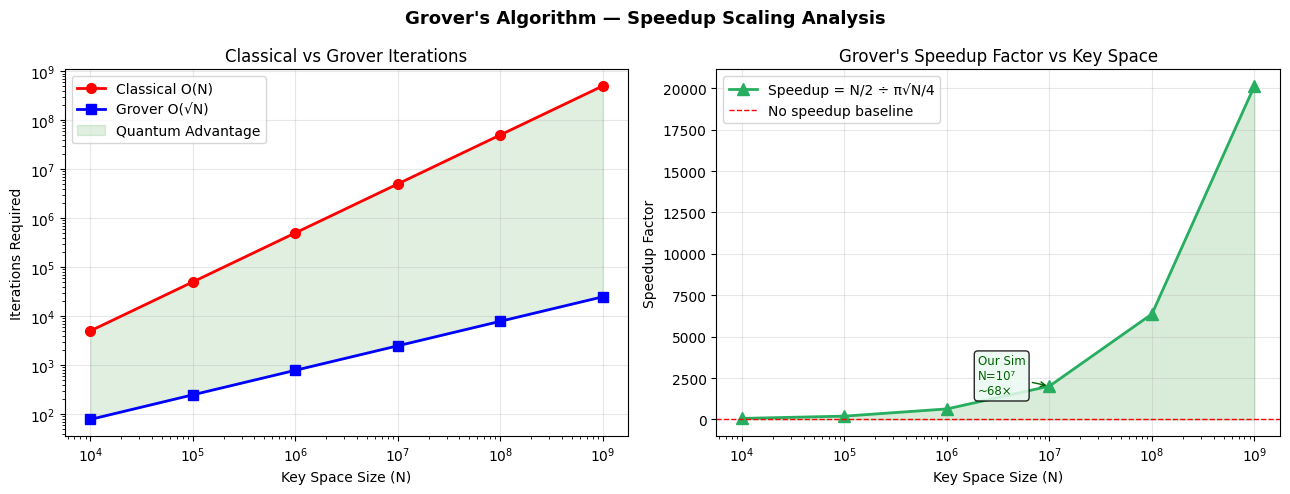

✅ Saved: grover_speedup_plot.png


In [ ]:
# ==========================================
# SCALING PLOT — Classical vs Grover
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Grover's Algorithm — Speedup Scaling Analysis", fontsize=13, fontweight='bold')

# Iterations comparison
ax = axes[0]
ax.loglog(key_spaces, c_iters, 'r-o', linewidth=2, markersize=7, label='Classical O(N)')
ax.loglog(key_spaces, g_iters, 'b-s', linewidth=2, markersize=7, label='Grover O(√N)')
ax.fill_between(key_spaces, g_iters, c_iters, alpha=0.12, color='green',
                label='Quantum Advantage')
ax.set_xlabel('Key Space Size (N)')
ax.set_ylabel('Iterations Required')
ax.set_title('Classical vs Grover Iterations')
ax.legend(); ax.grid(True, alpha=0.3)

# Speedup factor
ax2 = axes[1]
ax2.semilogx(key_spaces, speedups, 'g-^', linewidth=2, markersize=8,
             color='#27ae60', label='Speedup = N/2 ÷ π√N/4')
ax2.fill_between(key_spaces, 1, speedups, alpha=0.15, color='green')
ax2.set_xlabel('Key Space Size (N)')
ax2.set_ylabel('Speedup Factor')
ax2.set_title("Grover's Speedup Factor vs Key Space")
ax2.axhline(1, color='red', linestyle='--', linewidth=1, label='No speedup baseline')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Annotate our simulation point
ax2.annotate(f'Our Sim\nN=10⁷\n~68×',
             xy=(1e7, speedups[3]),
             xytext=(2e6, speedups[3] * 0.75),
             arrowprops=dict(arrowstyle='->', color='darkgreen'),
             fontsize=8.5, color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', alpha=0.85))

plt.tight_layout()
plt.savefig('grover_speedup_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: grover_speedup_plot.png")


/tmp/ipykernel_8220/1261318939.py:107: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8220/1261318939.py:107: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8220/1261318939.py:107: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8220/1261318939.py:107: UserWarning: Glyph 129694 (\N{MIRROR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8220/1261318939.py:107: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8220/1261318939.py:107: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8220/1261318939.py:108: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.savefig('nonqiskit_architecture.png', dpi=18

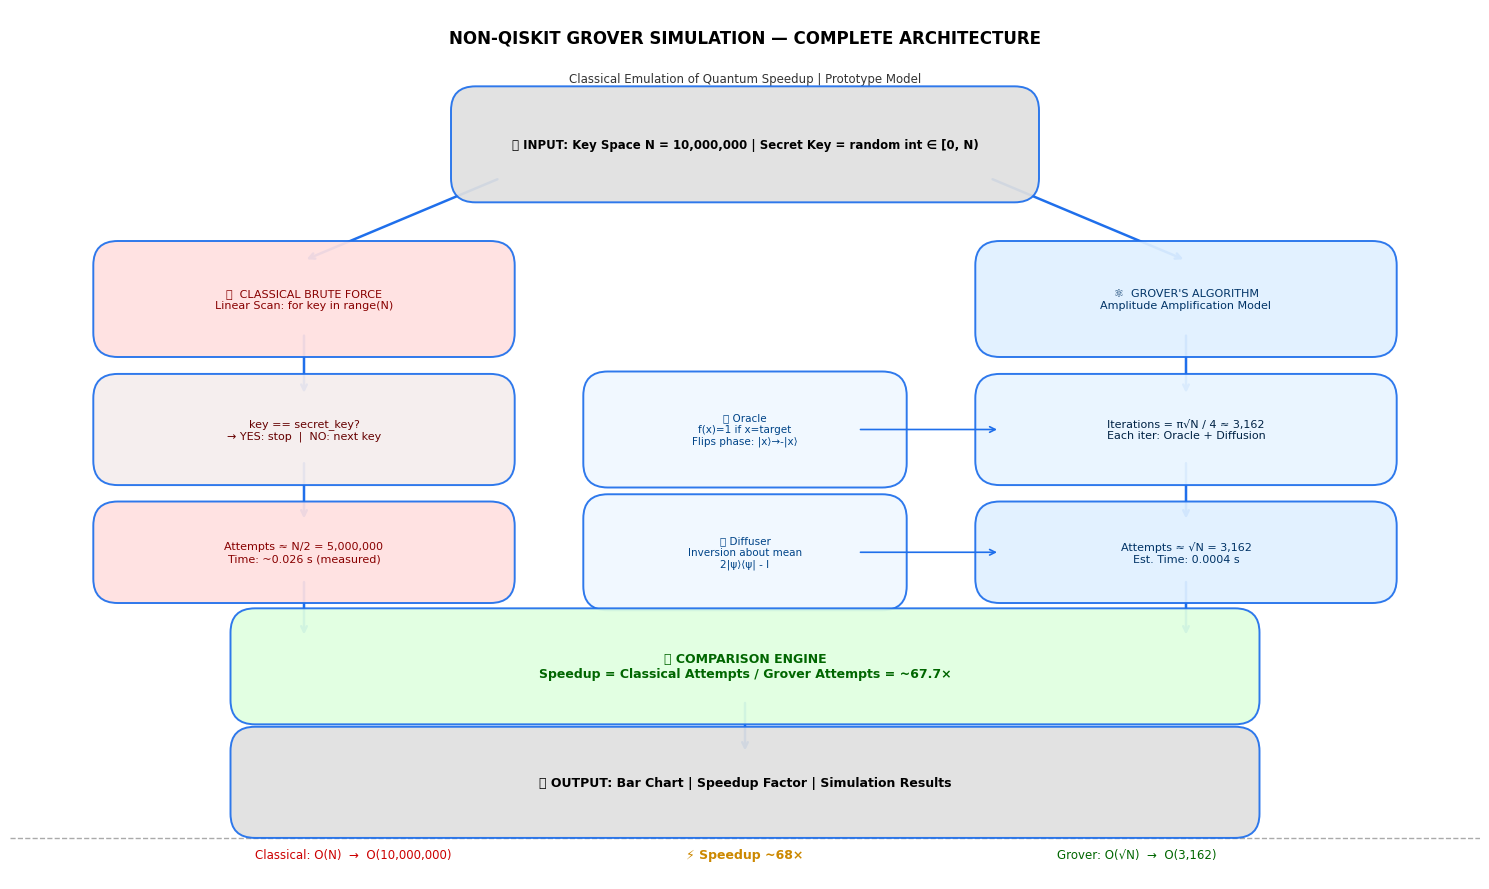

✅ Saved: nonqiskit_architecture.png


In [ ]:
# ==========================================
# ARCHITECTURE FLOWCHART
# Non-Qiskit Grover Simulation — Working Model
# ==========================================
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 15); ax.set_ylim(0, 9)
ax.axis('off')
fig.patch.set_facecolor('white') # Changed to white background
ax.set_facecolor('white')     # Changed to white background

def fbox(ax, x, y, w, h, text, fc='#d0e8ff', tc='black', fs=8.5, bold=False): # Updated default box colors for light background
    p = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.25', linewidth=1.4,
        edgecolor='#1f6feb', facecolor=fc, alpha=0.93, zorder=3) # Updated edge color
    ax.add_patch(p)
    ax.text(x, y, text, ha='center', va='center', color=tc,
            fontsize=fs, fontweight='bold' if bold else 'normal',
            zorder=4, multialignment='center')

def farrow(ax, x1, y1, x2, y2, lbl='', lc='#1f6feb'): # Updated default arrow color for light background
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=lc, lw=1.8), zorder=2)
    if lbl:
        mx, my = (x1+x2)/2+0.1, (y1+y2)/2
        ax.text(mx, my, lbl, color='#555555', fontsize=7.5, ha='left') # Darker label for light background

# Title
ax.text(7.5, 8.65, "NON-QISKIT GROVER SIMULATION — COMPLETE ARCHITECTURE",
        ha='center', color='black', fontsize=12, fontweight='bold') # Changed title color to black
ax.text(7.5, 8.25, "Classical Emulation of Quantum Speedup | Prototype Model",
        ha='center', color='#333333', fontsize=8.5) # Darker subtitle for light background

# Top input
fbox(ax, 7.5, 7.6, 5.5, 0.7,
     "📥 INPUT: Key Space N = 10,000,000 | Secret Key = random int ∈ [0, N)",
     fc='#e0e0e0', bold=True, tc='black') # Adjusted colors

# Split arrow
farrow(ax, 5, 7.25, 3, 6.4)
farrow(ax, 10, 7.25, 12, 6.4)

# Classical column
fbox(ax, 3, 6.0, 3.8, 0.7, """🖥  CLASSICAL BRUTE FORCE
Linear Scan: for key in range(N)""",
     fc='#ffe0e0', fs=8, tc='#880000') # Adjusted colors
farrow(ax, 3, 5.65, 3, 5.0)
fbox(ax, 3, 4.65, 3.8, 0.65, """key == secret_key?
→ YES: stop  |  NO: next key""",
     fc='#f5eded', fs=8, tc='#660000') # Adjusted colors
farrow(ax, 3, 4.33, 3, 3.7)
fbox(ax, 3, 3.38, 3.8, 0.55, """Attempts ≈ N/2 = 5,000,000
Time: ~0.026 s (measured)""",
     fc='#ffe0e0', fs=8, tc='#880000') # Adjusted colors

# Quantum column
fbox(ax, 12, 6.0, 3.8, 0.7, """⚛  GROVER'S ALGORITHM
Amplitude Amplification Model""",
     fc='#e0f0ff', fs=8, tc='#003366') # Adjusted colors
farrow(ax, 12, 5.65, 12, 5.0)
fbox(ax, 12, 4.65, 3.8, 0.65,
     """Iterations = π√N / 4 ≈ 3,162
Each iter: Oracle + Diffusion""",
     fc='#e9f5ff', fs=8, tc='#002244') # Adjusted colors
farrow(ax, 12, 4.33, 12, 3.7)
fbox(ax, 12, 3.38, 3.8, 0.55,
     """Attempts ≈ √N = 3,162
Est. Time: 0.0004 s""",
     fc='#e0f0ff', fs=8, tc='#003366') # Adjusted colors

# Oracle + Diffusion detail callout
fbox(ax, 7.5, 4.65, 2.8, 0.7,
     """🌀 Oracle
f(x)=1 if x=target
Flips phase: |x⟩→-|x⟩""",
     fc='#f0f8ff', fs=7.5, tc='#004488') # Adjusted colors
fbox(ax, 7.5, 3.38, 2.8, 0.7,
     """🪞 Diffuser
Inversion about mean
2|ψ⟩⟨ψ| - I""",
     fc='#f0f8ff', fs=7.5, tc='#004488') # Adjusted colors
ax.annotate('', xy=(8.65, 4.65), xytext=(10.1, 4.65),
            arrowprops=dict(arrowstyle='<-', color='#1f6feb', lw=1.2)) # Adjusted arrow color
ax.annotate('', xy=(8.65, 3.38), xytext=(10.1, 3.38),
            arrowprops=dict(arrowstyle='<-', color='#1f6feb', lw=1.2)) # Adjusted arrow color

# Merge to output
farrow(ax, 3, 3.1, 3, 2.5)
farrow(ax, 12, 3.1, 12, 2.5)
fbox(ax, 7.5, 2.2, 10, 0.7,
     """📊 COMPARISON ENGINE
Speedup = Classical Attempts / Grover Attempts = ~67.7×""",
     fc='#e0ffe0', bold=True, fs=9, tc='#006600') # Adjusted colors
farrow(ax, 7.5, 1.85, 7.5, 1.3)
fbox(ax, 7.5, 1.0, 10, 0.65,
     """📈 OUTPUT: Bar Chart | Speedup Factor | Simulation Results""",
     fc='#e0e0e0', bold=True, fs=9, tc='black') # Adjusted colors

# Complexity footer
ax.axhline(0.42, color='#aaaaaa', linewidth=1, linestyle='--') # Darker line for light background
ax.text(3.5, 0.22, "Classical: O(N)  →  O(10,000,000)", color='#cc0000', fontsize=8.5, ha='center') # Darker red
ax.text(11.5, 0.22, "Grover: O(√N)  →  O(3,162)", color='#006600', fontsize=8.5, ha='center') # Darker green
ax.text(7.5, 0.22, "⚡ Speedup ~68×", color='#cc8800', fontsize=9,
        fontweight='bold', ha='center') # Darker yellow/orange

plt.tight_layout()
plt.savefig('nonqiskit_architecture.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved: nonqiskit_architecture.png")
